In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

In [3]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
age_median=df['Age'].median()

In [6]:
age_median

28.0

In [7]:
df.fillna({'Age':age_median},inplace=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
df.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

<Axes: xlabel='Fare'>

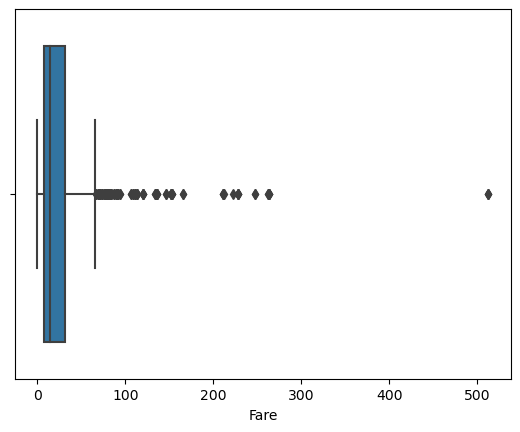

In [9]:
sns.boxplot(x=df['Fare'])

In [10]:
df=pd.get_dummies(df, columns=['Sex'],drop_first=True)

## separating text from number if text and number both are present in a column

In [11]:
df['Ticket_Number'] = df['Ticket'].str.extract('(\d+)')

In [12]:
df

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Ticket_Number
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,True,5
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,False,17599
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,False,113803
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,True,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,S,True,211536
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,S,False,112053
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,1,2,W./C. 6607,23.4500,NaN,S,False,6607
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,C,True,111369


In [13]:
df['Family_size']=df['SibSp']+df['Parch']

In [14]:
df

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male,Ticket_Number,Family_size
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,True,5,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,False,17599,1
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,2,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,False,113803,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,True,373450,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,S,True,211536,0
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,S,False,112053,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,1,2,W./C. 6607,23.4500,NaN,S,False,6607,3
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,C,True,111369,0


In [15]:
df.drop(columns=['Name','Ticket','PassengerId','Cabin'],inplace=True)

In [16]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,Sex_male,Ticket_Number,Family_size
0,0,3,22.0,1,0,7.2500,S,True,5,1
1,1,1,38.0,1,0,71.2833,C,False,17599,1
2,1,3,26.0,0,0,7.9250,S,False,2,0
3,1,1,35.0,1,0,53.1000,S,False,113803,1
4,0,3,35.0,0,0,8.0500,S,True,373450,0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,S,True,211536,0
887,1,1,19.0,0,0,30.0000,S,False,112053,0
888,0,3,28.0,1,2,23.4500,S,False,6607,3
889,1,1,26.0,0,0,30.0000,C,True,111369,0


In [17]:
df.dropna(subset=['Embarked'], inplace=True)

In [18]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,Sex_male,Ticket_Number,Family_size
0,0,3,22.0,1,0,7.2500,S,True,5,1
1,1,1,38.0,1,0,71.2833,C,False,17599,1
2,1,3,26.0,0,0,7.9250,S,False,2,0
3,1,1,35.0,1,0,53.1000,S,False,113803,1
4,0,3,35.0,0,0,8.0500,S,True,373450,0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,S,True,211536,0
887,1,1,19.0,0,0,30.0000,S,False,112053,0
888,0,3,28.0,1,2,23.4500,S,False,6607,3
889,1,1,26.0,0,0,30.0000,C,True,111369,0


In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       889 non-null    int64  
 1   Pclass         889 non-null    int64  
 2   Age            889 non-null    float64
 3   SibSp          889 non-null    int64  
 4   Parch          889 non-null    int64  
 5   Fare           889 non-null    float64
 6   Embarked       889 non-null    str    
 7   Sex_male       889 non-null    bool   
 8   Ticket_Number  885 non-null    str    
 9   Family_size    889 non-null    int64  
dtypes: bool(1), float64(2), int64(5), str(2)
memory usage: 70.3 KB


In [20]:
df.drop(columns=['Ticket_Number'], inplace=True)

In [22]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,Sex_male,Family_size
0,0,3,22.0,1,0,7.2500,S,True,1
1,1,1,38.0,1,0,71.2833,C,False,1
2,1,3,26.0,0,0,7.9250,S,False,0
3,1,1,35.0,1,0,53.1000,S,False,1
4,0,3,35.0,0,0,8.0500,S,True,0
...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,S,True,0
887,1,1,19.0,0,0,30.0000,S,False,0
888,0,3,28.0,1,2,23.4500,S,False,3
889,1,1,26.0,0,0,30.0000,C,True,0


In [23]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
from sklearn.preprocessing import StandardScaler
X=df.drop('Survived',axis=1)
y=df['Survived']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scale=StandardScaler()
X_train_scaled=scale.fit_transform(X_train)
X_test_scaled=scale.transform(X_test)
model=LogisticRegression()
model.fit(X_train_scaled,y_train)
prediction=model.predict(X_test_scaled)
print(f"the accuracy score of this model is : {accuracy_score(y_test,prediction)*100:.2f}%")
print(f"Classification report of this model is : \n{classification_report(y_test,prediction)}")
print(f"Confusion Matrix of this model is : {confusion_matrix(y_test,prediction)}")

the accuracy score of this model is : 76.97%
Classification report of this model is : 
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       109
           1       0.68      0.77      0.72        69

    accuracy                           0.77       178
   macro avg       0.76      0.77      0.76       178
weighted avg       0.78      0.77      0.77       178

Confusion Matrix of this model is : [[84 25]
 [16 53]]


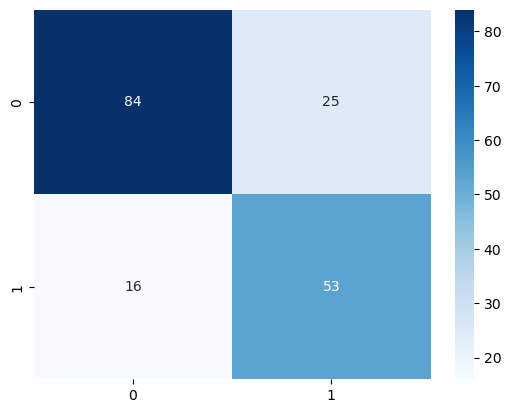

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test, prediction), annot=True, fmt='d', cmap='Blues')
plt.show()

In [26]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled,y_train)
prediction=model.predict(X_test_scaled)
print(f"the accuracy score of this model is : {accuracy_score(y_test,prediction)*100:.2f}%")
print(f"Classification report of this model is : \n{classification_report(y_test,prediction)}")
print(f"Confusion Matrix of this model is : {confusion_matrix(y_test,prediction)}")

the accuracy score of this model is : 78.65%
Classification report of this model is : 
              precision    recall  f1-score   support

           0       0.87      0.76      0.81       109
           1       0.69      0.83      0.75        69

    accuracy                           0.79       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.80      0.79      0.79       178

Confusion Matrix of this model is : [[83 26]
 [12 57]]


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,roc_auc_score
rfc=RandomForestClassifier(n_estimators=100,max_depth=5,max_features='sqrt',random_state=42)
rfc.fit(X_train_scaled,y_train)
pred=rfc.predict(X_test_scaled)
print(f"the accuracy score of randomforest model is : {accuracy_score(y_test,pred)*100:.2f}%")
print(f"the classification report of random forest model is : \n{classification_report(y_test,pred)}")
print(f"the confusion matrix of random forest model is : {confusion_matrix(y_test,pred)}")
print(f"the roc_auc_score of random forest model is : {roc_auc_score(y_test,pred)}")

the accuracy score of randomforest model is : 80.90%
the classification report of random forest model is : 
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       109
           1       0.78      0.71      0.74        69

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178

the confusion matrix of random forest model is : [[95 14]
 [20 49]]
the roc_auc_score of random forest model is : 0.7908522802818774


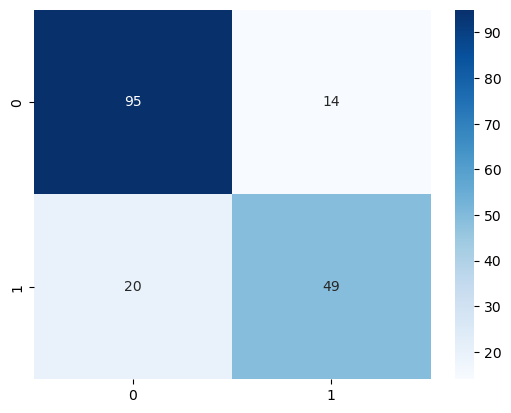

In [28]:
sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt='d',cmap='Blues')
plt.show()

In [29]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
rfc.fit(X_train_scaled,y_train)
pred=rfc.predict(X_test_scaled)
print(f"the accuracy score of randomforest model is : {accuracy_score(y_test,pred)*100:.2f}%")
print(f"the classification report of random forest model is : \n{classification_report(y_test,pred)}")
print(f"the confusion matrix of random forest model is : {confusion_matrix(y_test,pred)}")
print(f"the roc_auc_score of random forest model is : {roc_auc_score(y_test,pred)}")

the accuracy score of randomforest model is : 79.21%
the classification report of random forest model is : 
              precision    recall  f1-score   support

           0       0.87      0.78      0.82       109
           1       0.70      0.81      0.75        69

    accuracy                           0.79       178
   macro avg       0.78      0.80      0.79       178
weighted avg       0.80      0.79      0.79       178

the confusion matrix of random forest model is : [[85 24]
 [13 56]]
the roc_auc_score of random forest model is : 0.7957053583300093


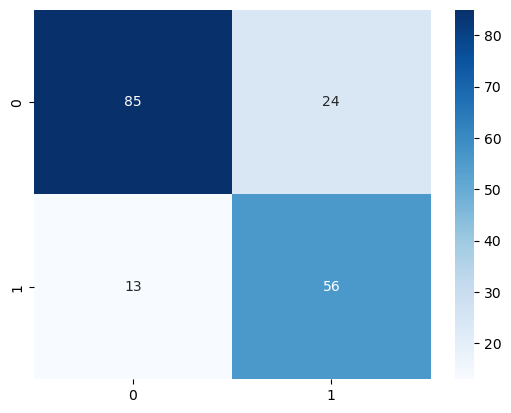

In [30]:
sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt='d',cmap='Blues')
plt.show()

In [31]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,roc_auc_score
gbc=GradientBoostingClassifier(n_estimators=100,max_depth=3,learning_rate=0.1)
score=cross_val_score(gbc,X_train_scaled,y_train,cv=5)
print(f"5 test individual score is : {score}")
print(f"the real avg (cross validated)accuracy:{score.mean()*100:.2f}%")

5 test individual score is : [0.82517483 0.81690141 0.80985915 0.85211268 0.82394366]
the real avg (cross validated)accuracy:82.56%


In [32]:
gbc.fit(X_train_scaled,y_train)
print(gbc.feature_importances_)

[0.13237428 0.13094657 0.02587033 0.00229744 0.17495792 0.43634591
 0.07388658 0.00257267 0.0207483 ]


In [33]:
predi = gbc.predict(X_test_scaled)
print(f"Final Accuracy: {accuracy_score(y_test, predi) * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, predi):.4f}\n")

Final Accuracy: 81.46%
ROC-AUC Score: 0.8034



In [34]:
import pickle
pickle.dump(gbc, open('titanic_gbc_model.pkl', 'wb'))